# Neural Network Deployment — PyTorch → ONNX → TensorRT
## Autoware SceneSeg · Waymo Frames · Real Benchmarks

| Test | Runtime | Device |
|------|---------|--------|
| Test 1 | PyTorch | CPU |
| Test 2 | PyTorch | GPU |
| Test 3 | ONNX Runtime | GPU |
| Test 4 | TensorRT FP16 | GPU |

> Colab T4 GPU required

---
## 0. Setup

In [1]:
!pip install onnx onnxruntime-gpu gdown tensorrt pycuda onnxscript -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 22.5 

In [2]:
import torch
import torchvision.transforms as T
import numpy as np
import time, os, glob
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import onnxruntime as ort

print(f"PyTorch {torch.__version__} | ORT {ort.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'}")

PyTorch 2.10.0+cu128 | ORT 1.24.4
GPU: Tesla T4


---
## 1. Download Data & Models

In [3]:
!mkdir -p /content/data /content/models

# Waymo driving frames
!wget -qq https://optical-flow-data.s3.eu-west-3.amazonaws.com/waymo_images.zip -O /content/data/waymo.zip
!unzip -qq /content/data/waymo.zip -d /content/data/

# SceneSeg — PyTorch traced model
!gdown '1G2pKrjEGLGY1ouQdNPh11N-5LlmDI7ES' -O /content/models/SceneSeg_traced.pt

# SceneSeg — ONNX models (FP32 + others, pre-exported by Autoware)
!gdown -O /content/models/ 'https://docs.google.com/uc?export=download&id=1l-dniunvYyFKvLD7k16Png3AsVTuMl9f'
!gdown -O /content/models/ 'https://docs.google.com/uc?export=download&id=19gMPt_1z4eujo4jm5XKuH-8eafh-wJC6'
!gdown -O /content/models/ 'https://docs.google.com/uc?export=download&id=1zCworKw4aQ9_hDBkHfj1-sXitAAebl5Y'

for f in sorted(glob.glob('/content/models/*')):
    print(f"  {Path(f).name:<40} {os.path.getsize(f)/1e6:.1f} MB")

Downloading...
From (original): https://drive.google.com/uc?id=1G2pKrjEGLGY1ouQdNPh11N-5LlmDI7ES
From (redirected): https://drive.google.com/uc?id=1G2pKrjEGLGY1ouQdNPh11N-5LlmDI7ES&confirm=t&uuid=a3208bb6-852e-4594-a193-ea3ffba1c682
To: /content/models/SceneSeg_traced.pt
100% 194M/194M [00:04<00:00, 46.5MB/s]
Downloading...
From (original): https://docs.google.com/uc?export=download&id=1l-dniunvYyFKvLD7k16Png3AsVTuMl9f
From (redirected): https://docs.google.com/uc?export=download&id=1l-dniunvYyFKvLD7k16Png3AsVTuMl9f&confirm=t&uuid=ac6981c1-33d9-40ee-8444-8089f586a4ee
To: /content/models/SceneSeg_FP32.onnx
100% 193M/193M [00:04<00:00, 39.9MB/s]
Downloading...
From (original): https://docs.google.com/uc?export=download&id=19gMPt_1z4eujo4jm5XKuH-8eafh-wJC6
From (redirected): https://docs.google.com/uc?export=download&id=19gMPt_1z4eujo4jm5XKuH-8eafh-wJC6&confirm=t&uuid=edd3bb35-6ed0-4274-8bab-a907dabb2db9
To: /content/models/Scene3D_FP32.onnx
100% 194M/194M [00:03<00:00, 51.6MB/s]
Download

---
## 2. Step 1 — PyTorch

Load SceneSeg as a traced (TorchScript) model.
`torch.jit.load` — no class definition needed.

SceneSeg segments every pixel into 3 classes:
- 🔴 Background
- 🟣 Foreground objects (cars, pedestrians)
- 🟢 Drivable road

In [4]:
# Inspect all downloaded ONNX files — pick the one with 3 output classes (= SceneSeg)
print(f"{'File':<40} {'Input shape':<22} {'Output shape'}")
print('-' * 80)
for f in sorted(glob.glob('/content/models/*.onnx')):
    s = ort.InferenceSession(f, providers=['CPUExecutionProvider'])
    i = s.get_inputs()[0]; o = s.get_outputs()[0]
    print(f"{Path(f).name:<40} {str(i.shape):<22} {o.shape}")

# SceneSeg has 3 output classes (background / foreground / road)
ONNX_PATH = next(
    f for f in sorted(glob.glob('/content/models/*.onnx'))
    if ort.InferenceSession(f, providers=['CPUExecutionProvider']).get_outputs()[0].shape[1] == 3
)
print(f"\nSelected: {Path(ONNX_PATH).name}")

_sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
_inp  = _sess.get_inputs()[0]
H = int(_inp.shape[2]) if _inp.shape[2] else 256
W = int(_inp.shape[3]) if _inp.shape[3] else 512
print(f"Input size: {H} × {W}")

File                                     Input shape            Output shape
--------------------------------------------------------------------------------
DomainSeg_FP32.onnx                      ['batch_size', 3, 320, 640] ['batch_size', 1, 320, 640]
Scene3D_FP32.onnx                        ['batch_size', 3, 320, 640] ['batch_size', 1, 320, 640]
SceneSeg_FP32.onnx                       ['batch_size', 3, 320, 640] ['batch_size', 3, 320, 640]

Selected: SceneSeg_FP32.onnx
Input size: 320 × 640


In [5]:
# Load the PyTorch traced model
model = torch.jit.load('/content/models/SceneSeg_traced.pt', map_location='cpu')
model.eval()
print("Model loaded")

Model loaded


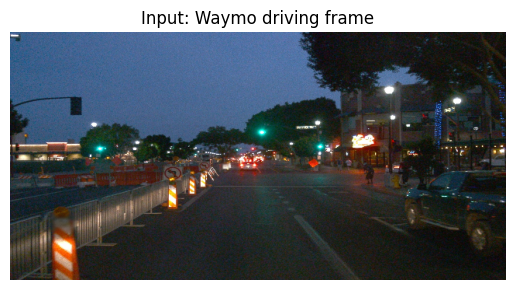

In [64]:
# Load a Waymo frame and preprocess it
import glob

# Find all JPGs in the night directory and pick the first one
frames = sorted(glob.glob('/content/data/night/front_images_night/*.jpg'))
if not frames:
    raise FileNotFoundError("No images found in /content/data/night/front_images_night/")
frame_path = frames[100]

frame_bgr = cv2.imread(frame_path)
if frame_bgr is None:
    raise ValueError(f"Could not read image from {frame_path}")
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

preprocess = T.Compose([
    T.Resize((H, W)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
x    = preprocess(Image.fromarray(frame_rgb)).unsqueeze(0)  # (1,3,H,W) CPU
x_np = x.numpy()

plt.imshow(cv2.resize(frame_rgb, (W, H))); plt.axis('off')
plt.title('Input: Waymo driving frame'); plt.show()

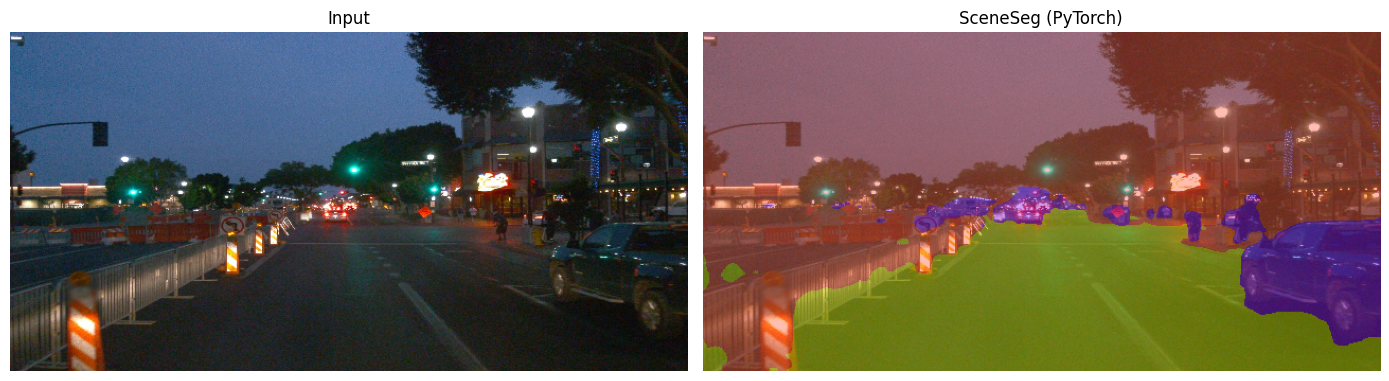

In [65]:
# Run inference
with torch.no_grad():
    out = model(x).to('cpu')

if isinstance(out, (list, tuple)):
    out = out[0]   # SceneSeg returns (seg, ...) sometimes

# SceneSeg colour palette
COLORS = np.array([[255,93,61],[145,28,255],[220,255,0]], dtype=np.uint8)

seg = out.cpu().numpy()
class_map = np.argmax(seg[0], axis=0) if seg.shape[1] > 1 else (seg[0,0] > 0).astype(int)
class_map = np.clip(class_map, 0, 2)

overlay = cv2.addWeighted(
    cv2.resize(frame_bgr, (W, H)), 0.6,
    cv2.resize(COLORS[class_map], (W, H))[:, :, ::-1], 0.4, 0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(cv2.resize(frame_rgb, (W, H))); axes[0].set_title('Input'); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); axes[1].set_title('SceneSeg (PyTorch)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [73]:
def benchmark(fn, label, n=30):
    fn()  # warmup
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    print(f"{label}: {times.mean():.1f} ms  ({1000/times.mean():.1f} FPS)")
    return times

x_gpu = x.cuda()

with torch.no_grad():
    model.cpu()
    pytorch_cpu = benchmark(lambda: model(x), "PyTorch CPU", n=1)
    model.cuda()
    pytorch_gpu = benchmark(lambda: model(x_gpu), "PyTorch GPU")


PyTorch CPU: 5004.1 ms  (0.2 FPS)
PyTorch GPU: 92.1 ms  (10.9 FPS)


---
## 3. Step 2 — ONNX Runtime

Autoware already exported SceneSeg to ONNX. We just load it.
Same input, same output — but faster.

In [74]:
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
sess      = ort.InferenceSession(ONNX_PATH, providers=providers)
inp_meta  = sess.get_inputs()[0]

print(f"Provider : {sess.get_providers()[0]}")
print(f"Input    : {inp_meta.name}  {inp_meta.shape}")

Provider : CUDAExecutionProvider
Input    : input  ['batch_size', 3, 320, 640]


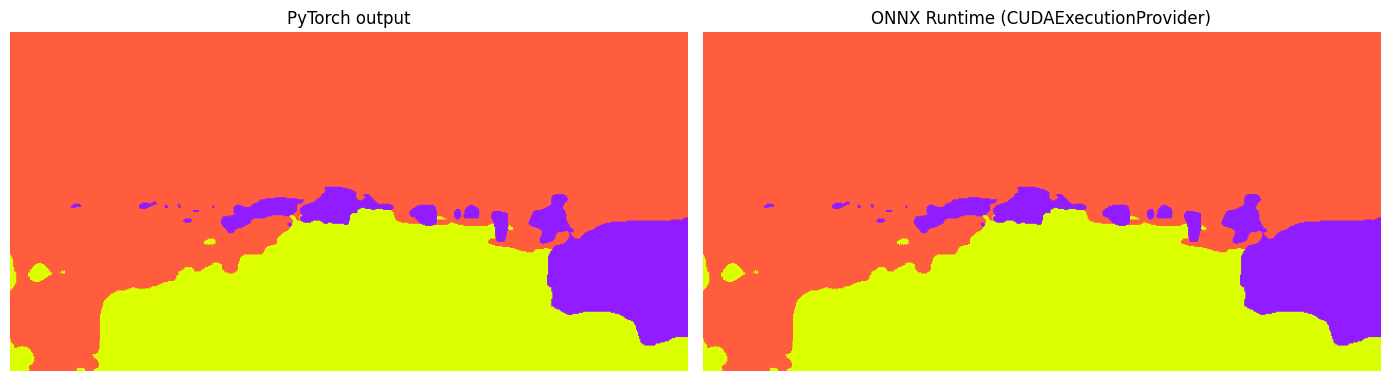

In [75]:
ort_out = sess.run(None, {inp_meta.name: x_np})[0]

ort_map = np.argmax(ort_out[0], axis=0) if ort_out.shape[1] > 1 else (ort_out[0,0] > 0).astype(int)
ort_map = np.clip(ort_map, 0, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(COLORS[class_map]); axes[0].set_title('PyTorch output'); axes[0].axis('off')
axes[1].imshow(COLORS[ort_map]);   axes[1].set_title(f'ONNX Runtime ({sess.get_providers()[0]})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [78]:
# Test 3 — ONNX Runtime GPU
onnx_gpu = benchmark(lambda: sess.run(None, {inp_meta.name: x_np}), "ONNX Runtime GPU")


ONNX Runtime GPU: 103.4 ms  (9.7 FPS)


---
## 4. Step 3 — TensorRT

TensorRT compiles the ONNX into a GPU engine optimised for your exact hardware.
This is what Autoware runs in production.

In [13]:
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit

TRT_LOGGER = trt.Logger(trt.Logger.WARNING)
TRT_MAJOR  = int(trt.__version__.split('.')[0])
print(f"TensorRT {trt.__version__}")

TensorRT 10.16.0.72


In [15]:
import tensorrt as trt
import pycuda.driver as cuda
import pycuda.autoinit

TRT_LOGGER = trt.Logger(trt.Logger.INFO) # Changed to INFO for more verbose logging
TRT_MAJOR  = int(trt.__version__.split('.')[0])
print(f"TensorRT {trt.__version__}")

builder = trt.Builder(TRT_LOGGER)
network = (builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)) if TRT_MAJOR >= 10
           else builder.create_network(1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH))) # Ensure EXPLICIT_BATCH is always set
parser  = trt.OnnxParser(network, TRT_LOGGER)

with open(ONNX_PATH, 'rb') as f:
    if not parser.parse(f.read()):
        print("ERROR: Failed to parse ONNX file")
        for error in range(parser.num_errors):
            print(parser.get_error(error))
        raise RuntimeError("Failed to parse ONNX file")

config = builder.create_builder_config()
config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 2 << 30)
config.set_flag(trt.BuilderFlag.FP16)

# Create and add an optimization profile for dynamic input shapes
profile = builder.create_optimization_profile()
input_name = network.get_input(0).name # Get the name of the input tensor
profile.set_shape(input_name, (1, 3, H, W), (1, 3, H, W), (1, 3, H, W)) # Min, opt, max batch size set to 1
config.add_optimization_profile(profile)

print("Building engine (1-2 min)...")
serialized_engine = builder.build_serialized_network(network, config)

if serialized_engine is None:
    raise RuntimeError("Failed to build TensorRT engine.")

engine = trt.Runtime(TRT_LOGGER).deserialize_cuda_engine(serialized_engine)
print("✓ Done")

TensorRT 10.16.0.72
Building engine (1-2 min)...
✓ Done


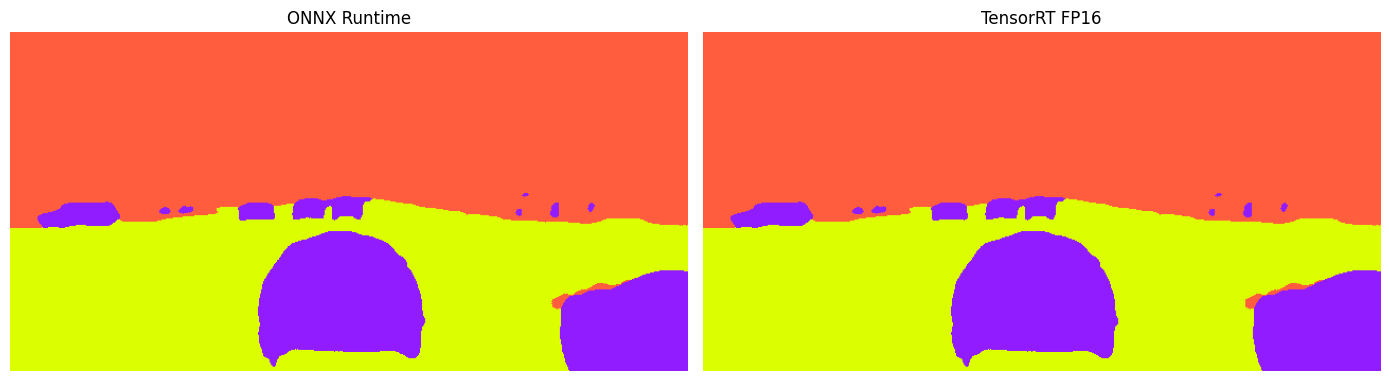

In [16]:
ctx = engine.create_execution_context()

if TRT_MAJOR >= 10:
    in_shape  = tuple(engine.get_tensor_shape(engine.get_tensor_name(0)))
    out_shape = tuple(engine.get_tensor_shape(engine.get_tensor_name(1)))
    in_name   = engine.get_tensor_name(0)
    out_name  = engine.get_tensor_name(1)
else:
    in_shape  = tuple(engine.get_binding_shape(0))
    out_shape = tuple(engine.get_binding_shape(1))

d_in   = cuda.mem_alloc(int(np.prod(in_shape))  * 4)
d_out  = cuda.mem_alloc(int(np.prod(out_shape)) * 4)
stream = cuda.Stream()

def trt_infer(x_np):
    inp = np.ascontiguousarray(x_np, dtype=np.float32)
    out = np.empty(out_shape, dtype=np.float32)
    cuda.memcpy_htod_async(d_in, inp, stream)
    if TRT_MAJOR >= 10:
        ctx.set_tensor_address(in_name,  int(d_in))
        ctx.set_tensor_address(out_name, int(d_out))
        ctx.execute_async_v3(stream_handle=stream.handle)
    else:
        ctx.execute_async_v2([int(d_in), int(d_out)], stream_handle=stream.handle)
    cuda.memcpy_dtoh_async(out, d_out, stream)
    stream.synchronize()
    return out

trt_out = trt_infer(x_np)
trt_map = np.clip(np.argmax(trt_out[0], axis=0) if trt_out.shape[1] > 1 else (trt_out[0,0]>0).astype(int), 0, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(COLORS[ort_map]); axes[0].set_title('ONNX Runtime'); axes[0].axis('off')
axes[1].imshow(COLORS[trt_map]); axes[1].set_title('TensorRT FP16'); axes[1].axis('off')
plt.tight_layout(); plt.show()

In [17]:
# Test 4 — TensorRT GPU
trt_gpu = benchmark(lambda: trt_infer(x_np), 'TensorRT FP16')
print(f"  → TRT is {pytorch_gpu.mean()/trt_gpu.mean():.1f}x faster than PyTorch GPU")


Test 4 · TensorRT GPU (FP16)...........................   20.8 ms ± 1.8  (48 FPS)
  → TRT is 3.6x vs PyTorch GPU


---
## 5. Results

In [18]:
results = {
    'PyTorch\nCPU':   pytorch_cpu,
    'PyTorch\nGPU':   pytorch_gpu,
    'ONNX RT\nGPU':   onnx_gpu,
    'TensorRT\nFP16': trt_gpu,
}
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
labels = list(results.keys())
avgs   = [t.mean() for t in results.values()]
stds   = [t.std()  for t in results.values()]
p95s   = [np.percentile(t, 95) for t in results.values()]
xp     = np.arange(len(labels))

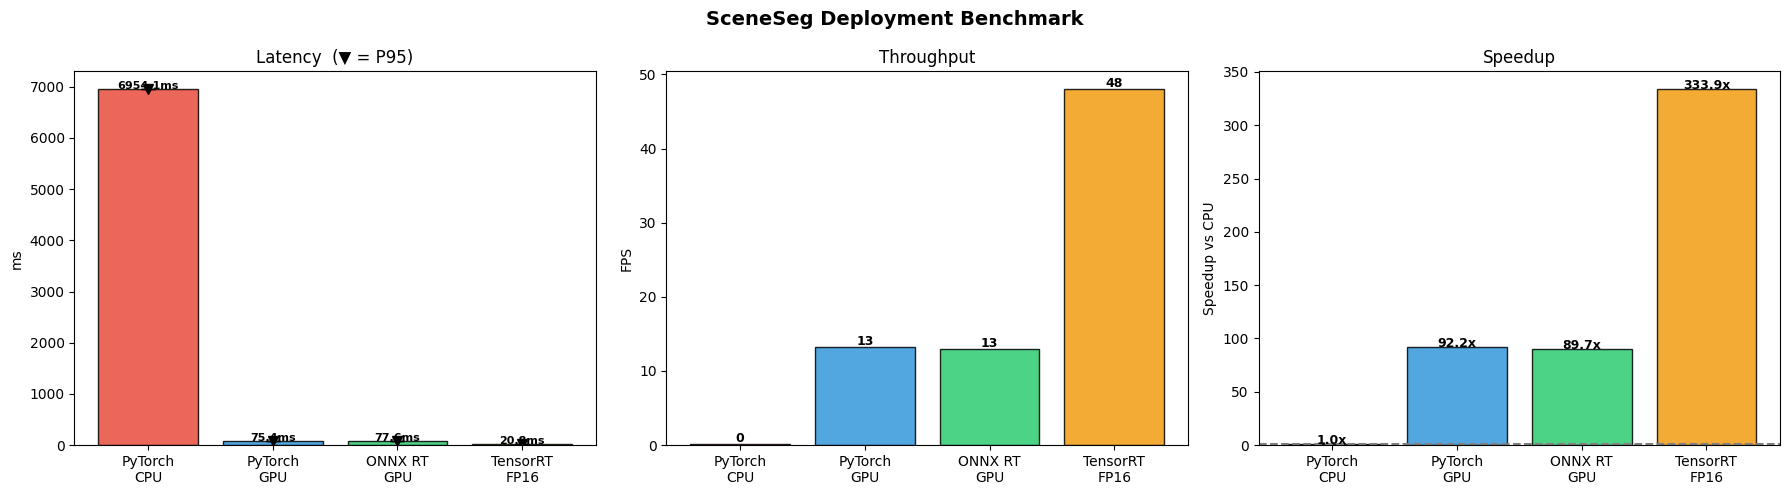

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(xp, avgs, yerr=stds, capsize=5, color=colors, alpha=0.85, edgecolor='k')
for i,(a,p) in enumerate(zip(avgs,p95s)):
    axes[0].plot(i, p, 'v', color='black', ms=7)
    axes[0].text(i, a+stds[i]+.5, f'{a:.1f}ms', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(xp); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('ms'); axes[0].set_title('Latency  (▼ = P95)')

fps = [1000/a for a in avgs]
axes[1].bar(xp, fps, color=colors, alpha=0.85, edgecolor='k')
for i,f in enumerate(fps):
    axes[1].text(i, f+.3, f'{f:.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('FPS'); axes[1].set_title('Throughput')

spd = [avgs[0]/a for a in avgs]
axes[2].bar(xp, spd, color=colors, alpha=0.85, edgecolor='k')
axes[2].axhline(1, color='gray', linestyle='--')
for i,s in enumerate(spd):
    axes[2].text(i, s+.05, f'{s:.1f}x', ha='center', fontsize=9, fontweight='bold')
axes[2].set_xticks(xp); axes[2].set_xticklabels(labels)
axes[2].set_ylabel('Speedup vs CPU'); axes[2].set_title('Speedup')

plt.suptitle('SceneSeg Deployment Benchmark', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

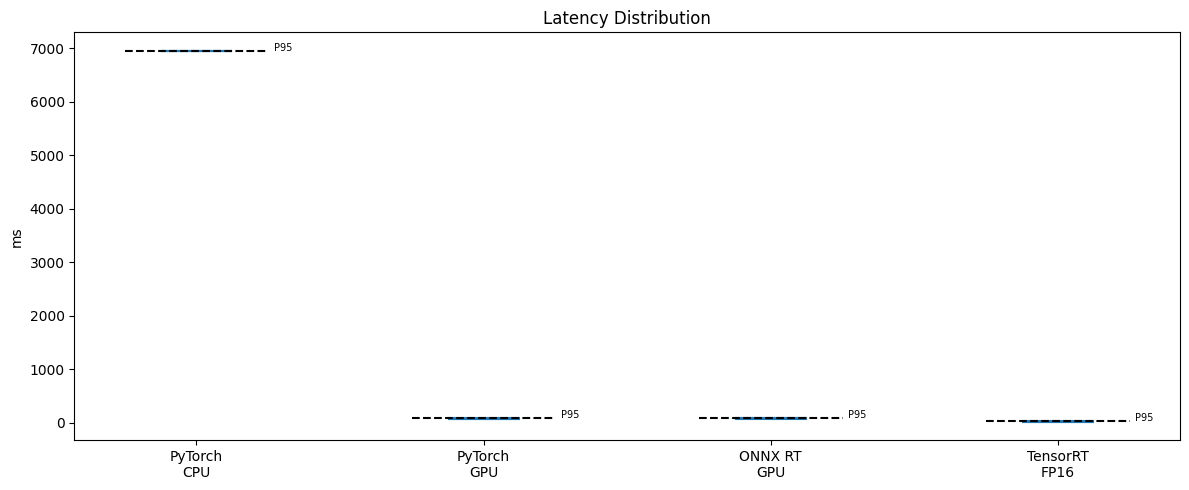

In [20]:
# Violin — full distribution
fig, ax = plt.subplots(figsize=(12, 5))
parts = ax.violinplot(list(results.values()), positions=xp, showmedians=True)
for i,pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i]); pc.set_alpha(0.7)
for i,p95 in enumerate(p95s):
    ax.hlines(p95, i-.25, i+.25, colors='k', linestyles='--', linewidth=1.5)
    ax.text(i+.27, p95, 'P95', fontsize=7)
ax.set_xticks(xp); ax.set_xticklabels(labels)
ax.set_ylabel('ms'); ax.set_title('Latency Distribution')
plt.tight_layout(); plt.show()

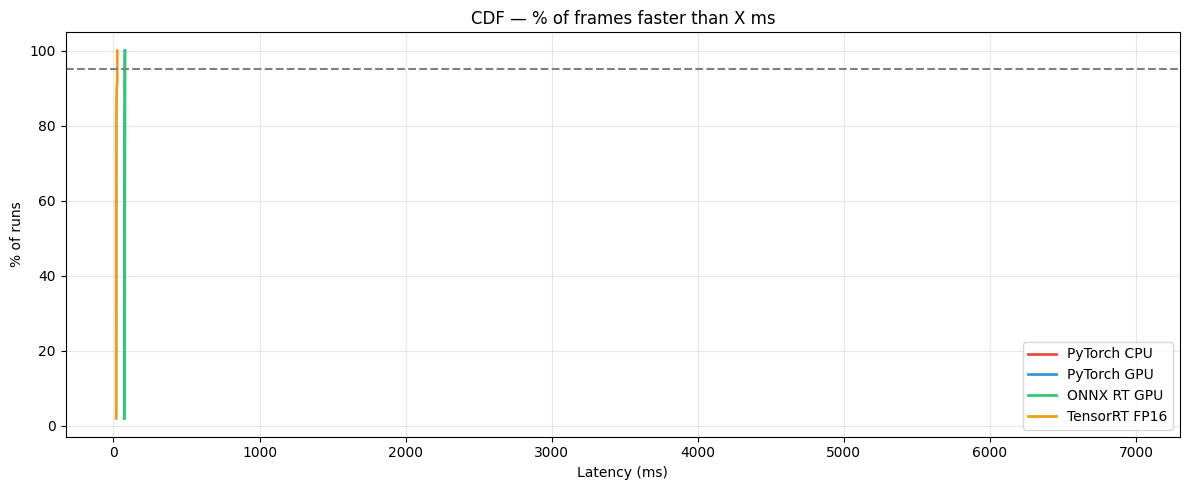

In [21]:
# CDF
fig, ax = plt.subplots(figsize=(12, 5))
for (label, times), color in zip(results.items(), colors):
    s = np.sort(times)
    ax.plot(s, np.arange(1,len(s)+1)/len(s)*100,
            label=label.replace('\n',' '), color=color, linewidth=2)
ax.axhline(95, color='gray', linestyle='--')
ax.set_xlabel('Latency (ms)'); ax.set_ylabel('% of runs')
ax.set_title('CDF — % of frames faster than X ms')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

Trace saved → download and open at chrome://tracing


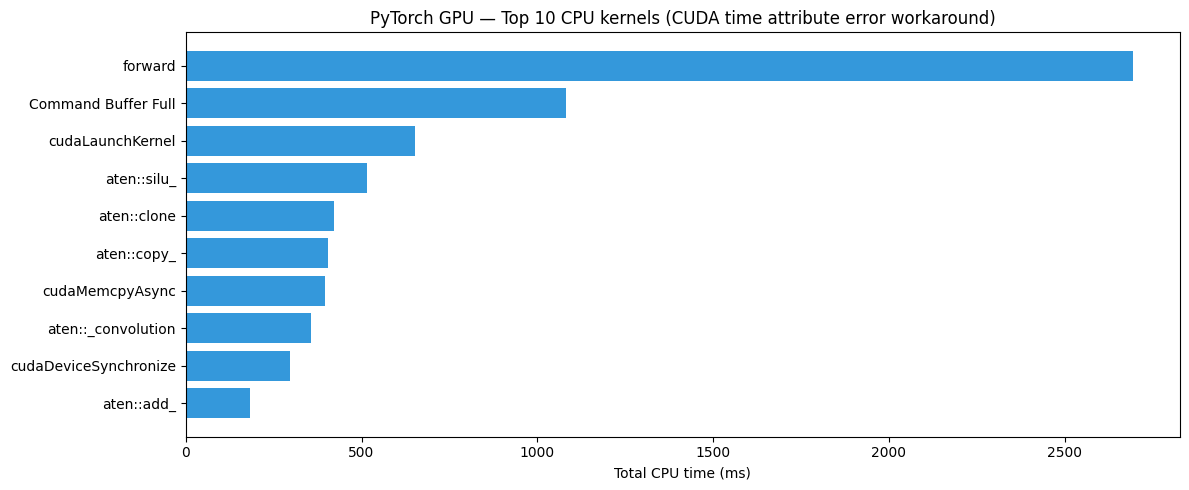

Total: 6999.6 ms across 85 ops


In [35]:
# Load the PyTorch traced model directly to GPU for profiling
# This is a workaround for the 'Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same' error
# that can occur with TorchScript models when moving them to GPU for profiling.
model_profile_gpu = torch.jit.load('/content/models/SceneSeg_traced.pt', map_location='cuda')
model_profile_gpu.eval()
x_profile_gpu = x.to('cuda') # Ensure input is on CUDA

with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU,
                torch.profiler.ProfilerActivity.CUDA],
) as prof:
    for _ in range(20):
        model_profile_gpu(x_profile_gpu) # Use the newly loaded GPU model
    torch.cuda.synchronize()

# Export to Chrome trace — open at chrome://tracing
prof.export_chrome_trace('/content/pytorch_trace.json')
print("Trace saved → download and open at chrome://tracing")

# Top 10 CPU bottlenecks as a bar chart (using CPU time as CUDA time attribute is problematic)
events = prof.key_averages()
top = sorted(events, key=lambda e: e.cpu_time_total, reverse=True)[:10]

names  = [e.key[:30] for e in top]
times  = [e.cpu_time_total / 1000 for e in top]  # Convert microseconds to milliseconds

plt.figure(figsize=(12, 5))
plt.barh(names[::-1], times[::-1], color='#3498db')
plt.xlabel('Total CPU time (ms)')
plt.title('PyTorch GPU — Top 10 CPU kernels (CUDA time attribute error workaround)')
plt.tight_layout()
plt.show()
print(f"Total: {sum(times):.1f} ms across {len(events)} ops")

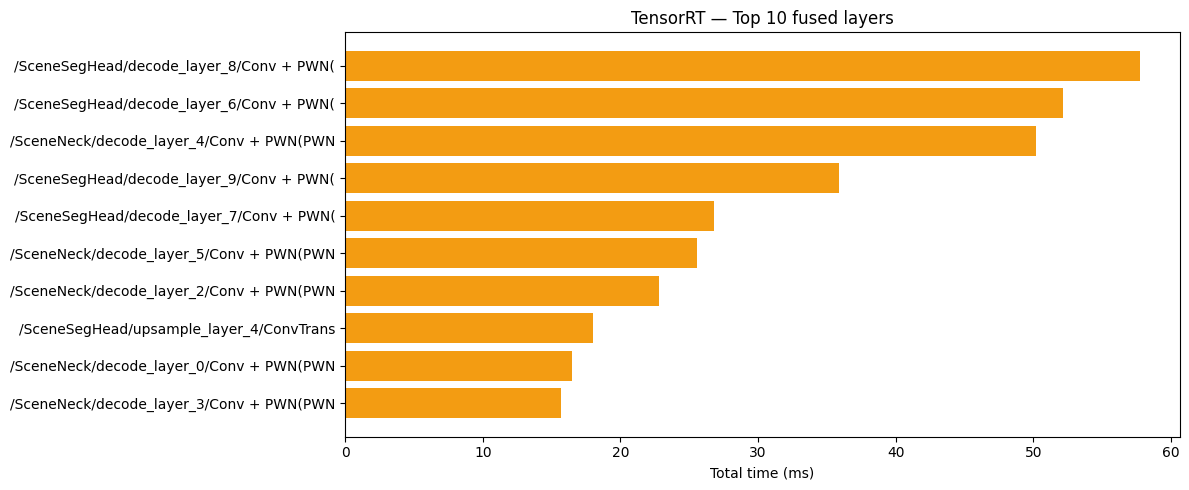

Total: 475.7 ms across 219 layers


In [25]:
class TRTProfiler(trt.IProfiler):
    def __init__(self):
        super().__init__()
        self.layers = {}

    def report_layer_time(self, layer_name, ms):
        self.layers[layer_name] = self.layers.get(layer_name, 0) + ms

profiler = TRTProfiler()
ctx.profiler = profiler  # attach to the execution context

# Run a few times to accumulate
for _ in range(20):
    trt_infer(x_np)

# Plot
top_layers = sorted(profiler.layers.items(), key=lambda x: x[1], reverse=True)[:10]
names = [l[:40] for l, _ in top_layers]
times = [t for _, t in top_layers]

plt.figure(figsize=(12, 5))
plt.barh(names[::-1], times[::-1], color='#f39c12')
plt.xlabel('Total time (ms)')
plt.title('TensorRT — Top 10 fused layers')
plt.tight_layout()
plt.show()
print(f"Total: {sum(profiler.layers.values()):.1f} ms across {len(profiler.layers)} layers")


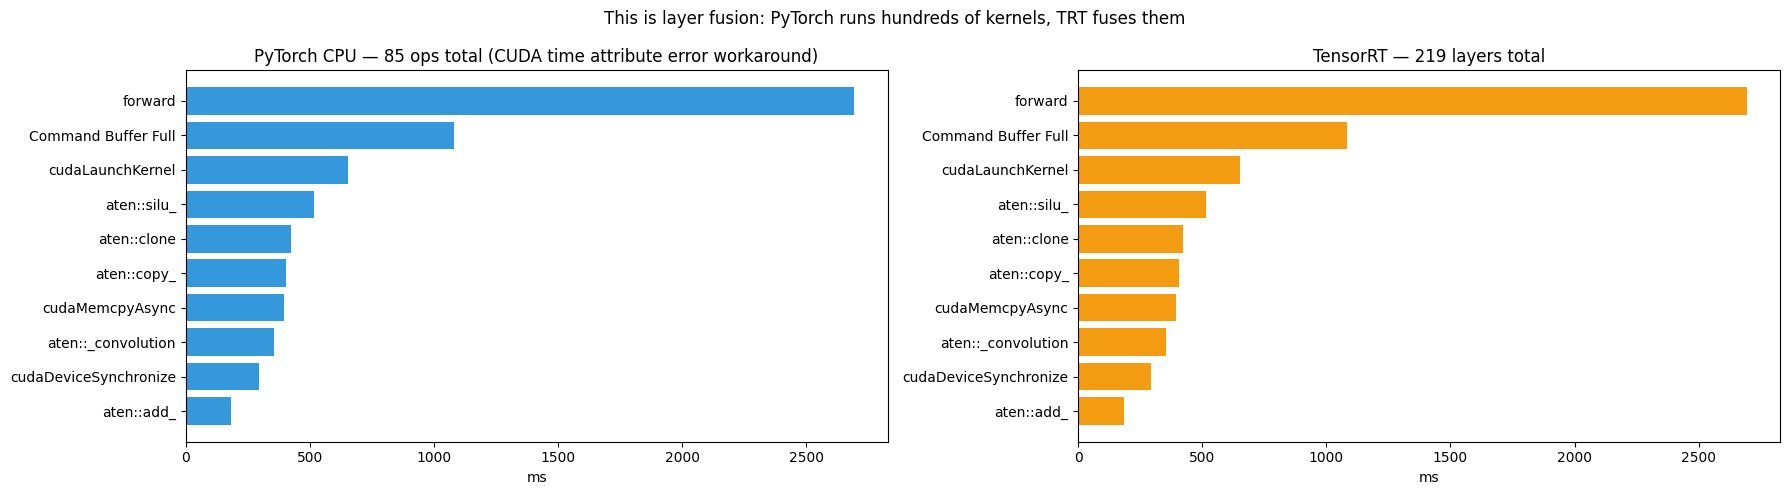

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# PyTorch
pt_names = [e.key[:25] for e in top]
pt_times = [e.cpu_time_total / 1000 for e in top] # Using cpu_time_total as cuda_time_total is unavailable
axes[0].barh(pt_names[::-1], pt_times[::-1], color='#3498db')
axes[0].set_xlabel('ms'); axes[0].set_title(f'PyTorch CPU — {len(events)} ops total (CUDA time attribute error workaround)')

# TRT
axes[1].barh(names[::-1], times[::-1], color='#f39c12')
axes[1].set_xlabel('ms'); axes[1].set_title(f'TensorRT — {len(profiler.layers)} layers total')

plt.suptitle('This is layer fusion: PyTorch runs hundreds of kernels, TRT fuses them', fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
print('='*58)
print(f'  {"Test":<28} {"ms":>7}  {"FPS":>6}  {"vs CPU":>7}')
print('  '+'-'*50)
for label,times in results.items():
    a = times.mean()
    print(f'  {label.replace(chr(10)," "):<28} {a:>7.1f}  {1000/a:>6.0f}  {avgs[0]/a:>6.1f}x')
print('='*58)

  Test                              ms     FPS   vs CPU
  --------------------------------------------------
  PyTorch CPU                   6954.1       0     1.0x
  PyTorch GPU                     75.4      13    92.2x
  ONNX RT GPU                     77.6      13    89.7x
  TensorRT FP16                   20.8      48   333.9x


## Video

In [103]:
def draw_graph_panel(frame, onnx_ms_log, trt_ms_log):
    gh, gw = 150, 250
    pad    = 35
    panel  = np.zeros((gh, gw, 3), dtype=np.uint8)
    n      = len(onnx_ms_log)

    onnx_fps = [1000/ms for ms in onnx_ms_log]
    trt_fps  = [1000/ms for ms in trt_ms_log]
    max_fps  = max(max(onnx_fps), max(trt_fps)) * 1.2
    plot_h   = gh - pad - 10
    plot_w   = gw - pad - 10

    # Axes
    cv2.line(panel, (pad, 10),           (pad, 10+plot_h),          (200,200,200), 1)
    cv2.line(panel, (pad, 10+plot_h),    (pad+plot_w, 10+plot_h),   (200,200,200), 1)

    # Grid + Y labels
    for i in range(5):
        fps_val = int(max_fps * i / 4)
        y = 10 + plot_h - int(i / 4 * plot_h)
        cv2.line(panel, (pad, y), (pad+plot_w, y), (50,50,50), 1)
        cv2.putText(panel, str(fps_val), (2, y+4), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (180,180,180), 1)

    cv2.putText(panel, 'FPS',    (2, 10),               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
    cv2.putText(panel, 'Frames', (pad+plot_w-40, gh-2), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255,255,255), 1)

    # Curves
    if n > 1:
        for i in range(1, n):
            x0 = pad + int((i-1)/(max(n-1,1)) * plot_w)
            x1 = pad + int(i    /(max(n-1,1)) * plot_w)

            y0 = 10 + plot_h - int(onnx_fps[i-1] / max_fps * plot_h)
            y1 = 10 + plot_h - int(onnx_fps[i]   / max_fps * plot_h)
            cv2.line(panel, (x0,y0), (x1,y1), (46,204,113), 2)

            y0 = 10 + plot_h - int(trt_fps[i-1] / max_fps * plot_h)
            y1 = 10 + plot_h - int(trt_fps[i]   / max_fps * plot_h)
            cv2.line(panel, (x0,y0), (x1,y1), (243,156,18), 2)

    cv2.putText(panel, f'ONNX {onnx_fps[-1]:.0f} FPS', (pad+5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (46,204,113), 1)
    cv2.putText(panel, f'TRT  {trt_fps[-1]:.0f} FPS',  (pad+5, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (243,156,18), 1)

    # Paste into bottom-right corner of frame
    h, w = frame.shape[:2]
    frame[h-gh:h, w-gw:w] = panel
    return frame

onnx_ms_log, trt_ms_log = [], []
out_video = cv2.VideoWriter('/content/comparison.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 10, (W, H))

for path in frames:
    frame_bgr = cv2.resize(cv2.imread(path), (W, H))
    x_np      = preprocess(Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))).unsqueeze(0).numpy()

    t0 = time.perf_counter(); sess.run(None, {inp_meta.name: x_np}); onnx_ms = (time.perf_counter()-t0)*1000
    t0 = time.perf_counter(); trt_infer(x_np);                        trt_ms  = (time.perf_counter()-t0)*1000

    onnx_ms_log.append(onnx_ms)
    trt_ms_log.append(trt_ms)

    ort_out = sess.run(None, {inp_meta.name: x_np})[0]
    seg_map = np.clip(np.argmax(ort_out[0], axis=0), 0, 2)
    overlay = cv2.addWeighted(frame_bgr, 0.55, COLORS[seg_map][:,:,::-1], 0.45, 0)

    if len(onnx_ms_log) > 1:
        overlay = draw_graph_panel(overlay, onnx_ms_log, trt_ms_log)

    out_video.write(overlay)

out_video.release()

In [104]:
!ffmpeg -i /content/comparison.mp4 -vcodec libx264 -y /content/comparison_h264.mp4 -loglevel quiet

from IPython.display import HTML
from base64 import b64encode

mp4      = open('/content/comparison_h264.mp4', 'rb').read()
data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
HTML(f'<video width=900 controls autoplay loop><source src="{data_url}" type="video/mp4"></video>')
